In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nagurmeeravalishaik","key":"6543a51a1108fa3fd08024564f17f913"}'}

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone")

print("Path to dataset files:", path)

100%|██████████| 1.52G/1.52G [01:13<00:00, 22.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1


In [4]:
import shutil

# Source path (where the dataset is currently located)
source_path = "/root/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1"

# Destination path (where you want to move the dataset)
destination_path = "/content/"

# Move the dataset
shutil.move(source_path, destination_path)

print("Dataset moved to:", destination_path)

Dataset moved to: /content/


In [5]:
# Data manipulation and processing
import numpy as np
import pandas as pd

# File handling and operations
import os
import glob
import random
import re
from collections import Counter

# Progress bar for loops
from tqdm import tqdm

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt  # Plotting library
import matplotlib.image as mpimg

# Image processing libraries
from PIL import Image
import cv2

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
base_dir = r'/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'

In [7]:
classes = os.listdir(base_dir)
classes

['Tumor', 'Cyst', 'Normal', 'Stone']

In [8]:
def make_df(classes,base_dir):
    data = []
    for label in classes:
        folder_path = os.path.join(base_dir, label)
        for file in os.listdir(folder_path):
            if file.endswith(('jpg','png')):
                file_path = os.path.join(folder_path, file)
                data.append((file_path, label))

    df = pd.DataFrame(data, columns=['file_path', 'label'])
    return df

In [9]:
df = make_df(classes,base_dir)
print("Shape of kidney dataset is:" ,df.shape)

Shape of kidney dataset is: (12446, 2)


In [10]:
df.head(10)

,file_path,label
0,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
1,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
2,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
3,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
4,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
5,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
6,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
7,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
8,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor
9,/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor...,Tumor


In [11]:
df['label'].value_counts()

,count
label,
Normal,5077
Cyst,3709
Tumor,2283
Stone,1377


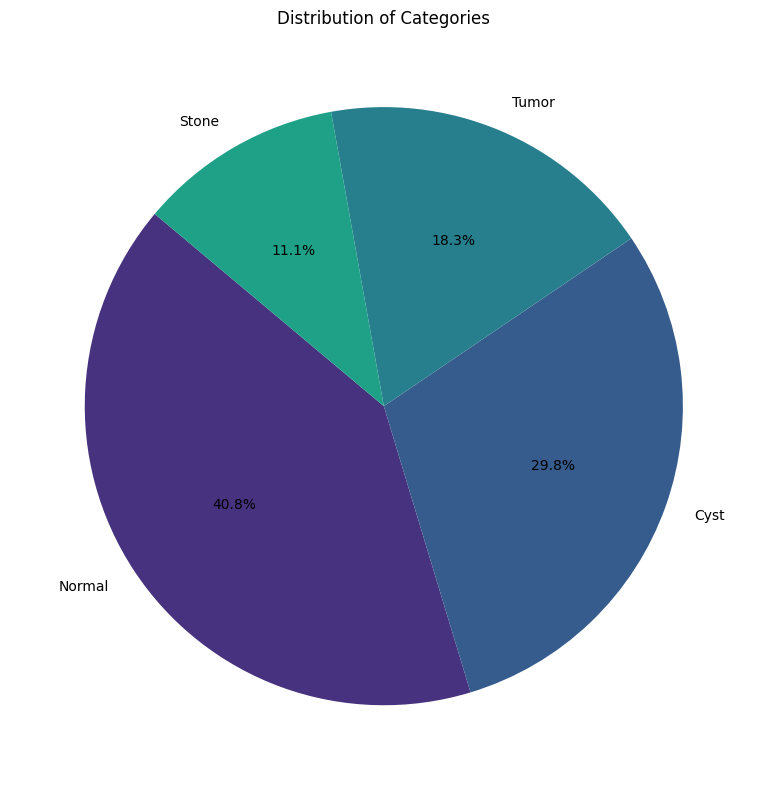

In [12]:
count = df['label'].value_counts()

palette = sns.color_palette("viridis")
colors = palette.as_hex()

plt.figure(figsize=(8, 8))
plt.pie(count, labels=count.index, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title('Distribution of Categories')

plt.tight_layout()

plt.show()

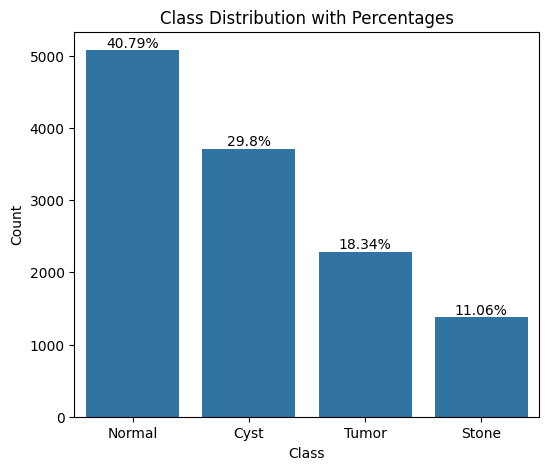

In [13]:
value_counts = df['label'].value_counts().reset_index()
value_counts.columns = ['label', 'count']
value_counts['percentage'] = (value_counts['count'] / value_counts['count'].sum() * 100).round(2)
plt.figure(figsize=(6,5))
ax = sns.barplot(data=value_counts, x='label', y='count')
for i, row in value_counts.iterrows():
    ax.text(i, row['count'], f"{row['percentage']}%", ha='center', va='bottom', fontsize=10, color='black')

plt.title("Class Distribution with Percentages")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the base directory and image types
base_dir = '/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'
image_types = ('.jpg', '.png', '.jpeg')  # Include other relevant image types if needed

In [15]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

In [ ]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

In [16]:
# Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import os
import json
from datetime import datetime
import shutil
from pathlib import Path

# Mount Google Drive (if your dataset is stored there)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
# Define paths
dataset_path = '/content/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'
output_path = '/content/kidney_dataset'

# Print original dataset statistics
def print_original_stats():
    print("Original Dataset Statistics:")
    print("-" * 50)
    classes = ['Normal', 'Cyst', 'Tumor', 'Stone']
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        print(f"{class_name}: {count} images")
    print("-" * 50)

print_original_stats()

# Create output directories
def create_dataset_structure():
    # Create main directories
    os.makedirs(os.path.join(output_path, 'train'), exist_ok=True)
    os.makedirs(os.path.join(output_path, 'validation'), exist_ok=True)
    os.makedirs(os.path.join(output_path, 'test'), exist_ok=True)

    # Create class directories
    classes = ['Normal', 'Cyst', 'Tumor', 'Stone']
    for split in ['train', 'validation', 'test']:
        for class_name in classes:
            os.makedirs(os.path.join(output_path, split, class_name), exist_ok=True)

# Split dataset into train/validation/test
def split_dataset():
    # Define split ratios
    train_ratio = 0.7
    val_ratio = 0.15
    test_ratio = 0.15

    # Process each class
    classes = ['Normal', 'Cyst', 'Tumor', 'Stone']
    for class_name in classes:
        # Get all files for the class
        class_path = os.path.join(dataset_path, class_name)
        files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        # Shuffle files
        np.random.shuffle(files)

        # Calculate split indices
        n_files = len(files)
        train_end = int(n_files * train_ratio)
        val_end = train_end + int(n_files * val_ratio)

        # Split files
        train_files = files[:train_end]
        val_files = files[train_end:val_end]
        test_files = files[val_end:]

        # Copy files to respective directories
        for file in train_files:
            src = os.path.join(class_path, file)
            dst = os.path.join(output_path, 'train', class_name, file)
            shutil.copy2(src, dst)

        for file in val_files:
            src = os.path.join(class_path, file)
            dst = os.path.join(output_path, 'validation', class_name, file)
            shutil.copy2(src, dst)

        for file in test_files:
            src = os.path.join(class_path, file)
            dst = os.path.join(output_path, 'test', class_name, file)
            shutil.copy2(src, dst)

# Create dataset structure and split
create_dataset_structure()
split_dataset()

# Print dataset statistics after splitting
def print_split_stats():
    splits = ['train', 'validation', 'test']
    classes = ['Normal', 'Cyst', 'Tumor', 'Stone']

    print("\nSplit Dataset Statistics:")
    print("-" * 50)
    for split in splits:
        print(f"\n{split.capitalize()} Set:")
        total = 0
        for class_name in classes:
            count = len(os.listdir(os.path.join(output_path, split, class_name)))
            total += count
            print(f"{class_name}: {count} images")
        print(f"Total: {total} images")
    print("-" * 50)

print_split_stats()

Original Dataset Statistics:
--------------------------------------------------
Normal: 5077 images
Cyst: 3709 images
Tumor: 2283 images
Stone: 1377 images
--------------------------------------------------

Split Dataset Statistics:
--------------------------------------------------

Train Set:
Normal: 3553 images
Cyst: 2596 images
Tumor: 1598 images
Stone: 963 images
Total: 8710 images

Validation Set:
Normal: 761 images
Cyst: 556 images
Tumor: 342 images
Stone: 206 images
Total: 1865 images

Test Set:
Normal: 763 images
Cyst: 557 images
Tumor: 343 images
Stone: 208 images
Total: 1871 images
--------------------------------------------------


In [ ]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Assuming 'X' is your feature data and 'y' is your target variable (class labels)
# You'll need to extract these from your image data (e.g., using ImageDataGenerator)

# 1. Oversampling with SMOTE
oversample = SMOTE(sampling_strategy='auto')  # Adjust sampling_strategy if needed
X_over, y_over = oversample.fit_resample(X, y)

# 2. Undersampling with RandomUnderSampler
undersample = RandomUnderSampler(sampling_strategy='auto')  # Adjust sampling_strategy if needed
X_under, y_under = undersample.fit_resample(X, y)

# Check class distribution after balancing
print("Original class distribution:", Counter(y))
print("Class distribution after oversampling:", Counter(y_over))
print("Class distribution after undersampling:", Counter(y_under))

In [18]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Apply various image processing techniques:
    1. Resize
    2. Normalization
    3. Contrast Enhancement
    4. Noise Reduction
    5. Edge Enhancement
    """
    # Read image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, target_size)

    # Normalization
    img = img / 255.0

    # Contrast Enhancement using CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    enhanced_img = cv2.merge((cl,a,b))
    enhanced_img = cv2.cvtColor(enhanced_img, cv2.COLOR_LAB2RGB)

    # Noise Reduction using Gaussian Blur
    denoised_img = cv2.GaussianBlur(enhanced_img, (3,3), 0)

    # Edge Enhancement using Laplacian
    gray = cv2.cvtColor(denoised_img, cv2.COLOR_RGB2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    laplacian = cv2.normalize(laplacian, None, 0, 1, cv2.NORM_MINMAX)

    return denoised_img

In [19]:
def create_model(input_shape=(224, 224, 3), num_classes=4):
    """
    Create a CNN model with:
    1. Convolutional layers
    2. Batch normalization
    3. Dropout
    4. Dense layers
    """
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fourth Convolutional Block
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [20]:
def train_model(model, train_generator, val_generator, epochs=50):
    """
    Train the model with callbacks and evaluate performance
    """
    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6
        )
    ]

    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train model
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=callbacks
    )

    return history

def evaluate_model(model, test_generator):
    """
    Evaluate model performance and generate metrics
    """
    # Get predictions
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_generator.classes

    # Generate classification report
    class_names = list(test_generator.class_indices.keys())
    report = classification_report(y_true, y_pred_classes, target_names=class_names)

    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    return report, cm

In [21]:
def save_model(model, model_name="kidney_disease_model"):
    """Save the model and its weights."""
    if not os.path.exists('models'):
        os.makedirs('models')

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save the entire model
    model_path = os.path.join('models', f'{model_name}_{timestamp}.keras')
    model.save(model_path)

    # Save model weights with .weights.h5 extension
    weights_path = os.path.join('models', f'{model_name}_{timestamp}.weights.h5')  # Changed extension
    model.save_weights(weights_path)

    print(f"Model saved to: {model_path}")
    print(f"Weights saved to: {weights_path}")

    return model_path, weights_path

def load_model(model_path):
    """Load a saved model"""
    try:
        model = tf.keras.models.load_model(model_path)
        print(f"Model loaded successfully from {model_path}")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

def load_weights(model, weights_path):
    """Load weights into a model"""
    try:
        model.load_weights(weights_path)
        print(f"Weights loaded successfully from {weights_path}")
        return model
    except Exception as e:
        print(f"Error loading weights: {e}")
        return None

In [22]:
def plot_training_history(history):
    """
    Plot training and validation accuracy/loss
    """
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

Found 8710 images belonging to 4 classes.
Found 1865 images belonging to 4 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,269,316 (73.51 MB)

 Trainable params: 19,267,332 (73.50 MB)

...


Training the model...
Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5567 - loss: 1.4717

137/137 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.5571 - loss: 1.4693 - val_accuracy: 0.2981 - val_loss: 27.6673 - learning_rate: 0.0010
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.6794 - loss: 0.8558 - val_accuracy: 0.2981 - val_loss: 43.1892 - learning_rate: 0.0010
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.7079 - loss: 0.7368 - val_accuracy: 0.1936 - val_loss: 24.3390 - learning_rate: 0.0010
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.7630 - loss: 0.6208 - val_accuracy: 0.2241 - val_loss: 13.1073 - learning_rate: 0.0010
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.7750 - loss: 0.5437 - val_accuracy: 0.1282 - val_loss: 10.4504 - learning_rate: 0.0010
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8129 - loss: 0.4559 - val_accuracy: 0.1818 - val_loss: 7.4519 - learning_rate: 0.0010
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8267 - loss: 0.4326

137/137 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8268 - loss: 0.4326 - val_accuracy: 0.5887 - val_loss: 1.5295 - learning_rate: 0.0010
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8507 - loss: 0.3728 - val_accuracy: 0.3528 - val_loss: 6.5316 - learning_rate: 0.0010
Epoch 9/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8694 - loss: 0.3358

137/137 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8694 - loss: 0.3357 - val_accuracy: 0.5995 - val_loss: 1.8251 - learning_rate: 0.0010
Epoch 10/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8808 - loss: 0.3022

137/137 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8808 - loss: 0.3022 - val_accuracy: 0.8992 - val_loss: 0.2952 - learning_rate: 0.0010
Epoch 11/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8939 - loss: 0.2668 - val_accuracy: 0.3721 - val_loss: 4.7419 - learning_rate: 0.0010
Epoch 12/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.8935 - loss: 0.2712 - val_accuracy: 0.2204 - val_loss: 10.1294 - learning_rate: 0.0010
Epoch 13/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9211 - loss: 0.2100 - val_accuracy: 0.4059 - val_loss: 7.2107 - learning_rate: 0.0010
Epoch 14/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9399 - loss: 0.1691 - val_accuracy: 0.6252 - val_loss: 2.0956 - learning_rate: 2.0000e-04
Epoch 15/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9512 - loss: 0.1337 - val_accuracy: 0.6595 - val_loss: 2.3488 - learning_rate: 2.0000e-04


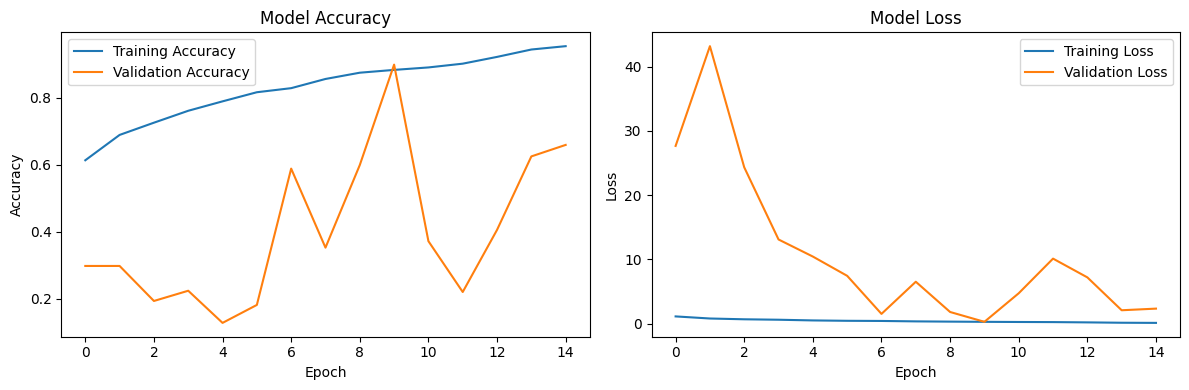

Model saved to: models/kidney_disease_model_20250424_221407.keras
Weights saved to: models/kidney_disease_model_20250424_221407.weights.h5

Evaluating the model...
Found 1871 images belonging to 4 classes.
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 337ms/step

Classification Report:
              precision    recall  f1-score   support

        Cyst       0.32      0.30      0.31       557
      Normal       0.40      0.37      0.39       763
       Stone       0.07      0.09      0.08       208
       Tumor       0.22      0.24      0.23       343

    accuracy                           0.30      1871
   macro avg       0.25      0.25      0.25      1871
weighted avg       0.31      0.30      0.30      1871



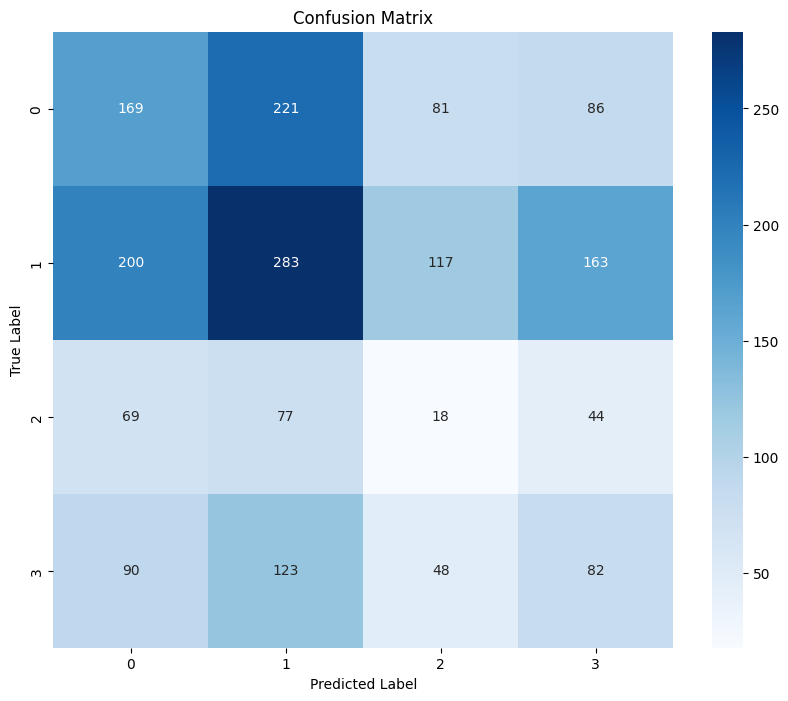

In [24]:
# Enable mixed precision training for faster performance
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Clear any existing models from memory
tf.keras.backend.clear_session()

# Set memory growth for GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)

# Set paths to your dataset
train_dir = '/content/kidney_dataset/train'
val_dir = '/content/kidney_dataset/validation'
test_dir = '/content/kidney_dataset/test'

# Optimize data loading
BATCH_SIZE = 64  # Increased batch size for faster training

# Create optimized data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Create and compile model with optimized settings
model = create_model()  # Using our custom CNN model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# Callbacks for optimized training
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

# Train the model with optimized settings
print("\nTraining the model...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # Reduced epochs, will stop early if needed
    callbacks=callbacks
)

# Plot training history
plot_training_history(history)

# Save the model
model_path, weights_path = save_model(model)

# Evaluate the model
print("\nEvaluating the model...")
test_datagen = ImageDataGenerator(
    rescale=1./255
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

report, cm = evaluate_model(model, test_generator)
print("\nClassification Report:")
print(report)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

In [ ]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

In [ ]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

In [ ]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

In [ ]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

In [ ]:
def process_and_display_image(image_path):
    """
    Loads, preprocesses, segments, and displays a single image.

    Args:
        image_path (str): Path to the image file.
    """
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply median filtering for noise reduction
    filtered_image = cv2.medianBlur(image, 5)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(filtered_image)

    # Apply Otsu's thresholding
    _, thresholded_image = cv2.threshold(enhanced_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations (optional)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opening = cv2.morphologyEx(thresholded_image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # (Optional) Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title('Enhanced Image')
    plt.subplot(1, 3, 3)
    plt.imshow(closing, cmap='gray')
    plt.title('Segmented Image')
    plt.show()

Found 8710 images belonging to 4 classes.
Found 1865 images belonging to 4 classes.
Found 1871 images belonging to 4 classes.
137/137 ━━━━━━━━━━━━━━━━━━━━ 44s 318ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 329ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 345ms/step

Overall Model Accuracies:
Training Accuracy: 0.9104
Validation Accuracy: 0.8992
Test Accuracy: 0.9193

Class-wise Accuracies:

Train Set:
Cyst: 0.9079
Normal: 0.9006
Stone: 0.9148
Tumor: 0.9337

Val Set:
Cyst: 0.8903
Normal: 0.8896
Stone: 0.9320
Tumor: 0.9152

Test Set:
Cyst: 0.9192
Normal: 0.9096
Stone: 0.9183
Tumor: 0.9417


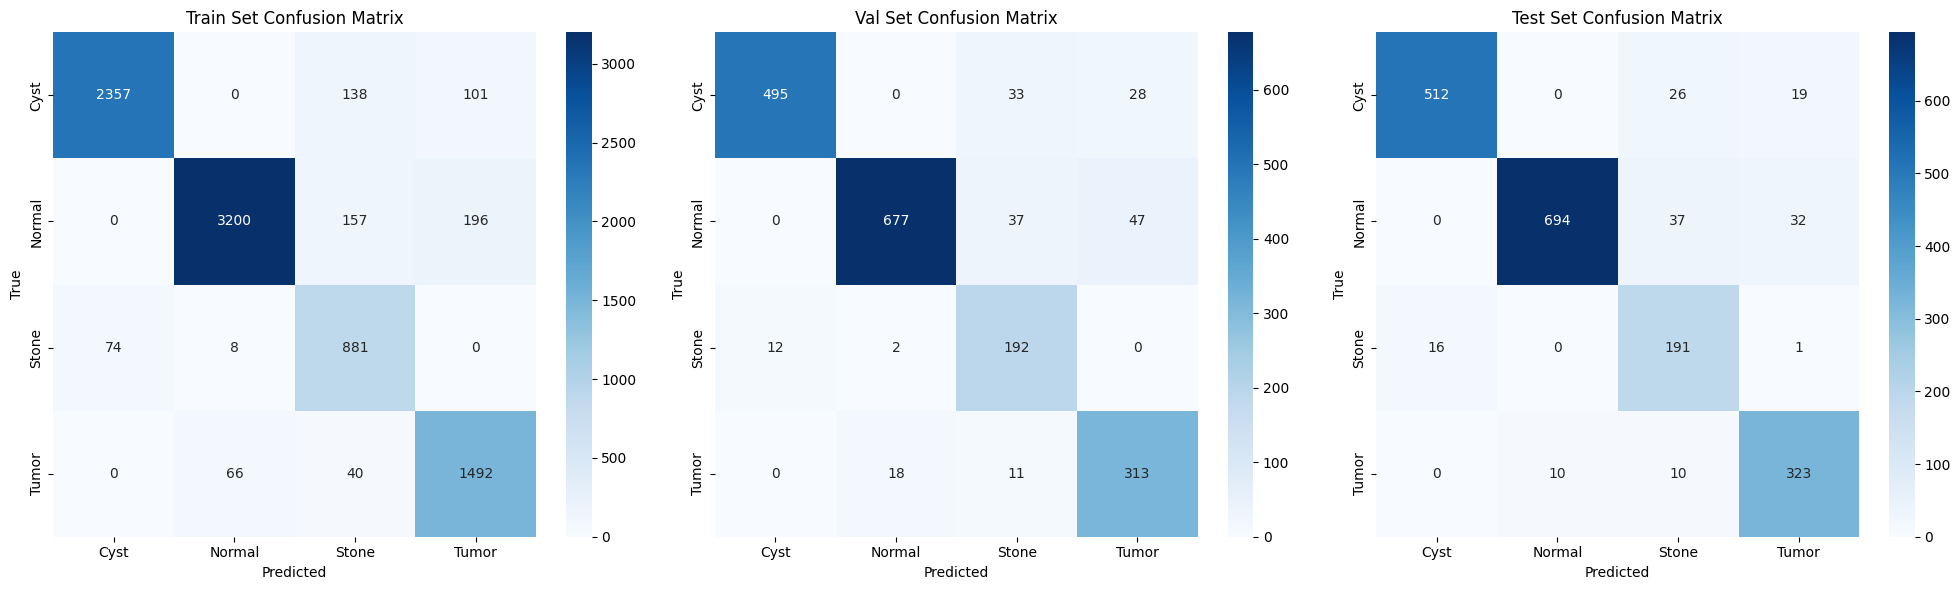

In [43]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil
from PIL import Image

def save_true_positives(generator, predictions, output_dir):
    """
    Save true positive predictions to separate folders for each class.

    Args:
        generator: ImageDataGenerator
        predictions: Model predictions
        output_dir: Base directory to save true positives
    """
    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Get class names
    class_names = list(generator.class_indices.keys())

    # Create subdirectories for each class
    for class_name in class_names:
        class_dir = os.path.join(output_dir, class_name)
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)

    # Get true and predicted labels
    true_classes = generator.classes
    pred_classes = np.argmax(predictions, axis=1)

    # Get file paths
    file_paths = generator.filepaths

    # Save true positives
    for idx, (true_class, pred_class) in enumerate(zip(true_classes, pred_classes)):
        if true_class == pred_class:  # True positive
            class_name = class_names[true_class]
            src_path = file_paths[idx]
            filename = os.path.basename(src_path)
            dst_path = os.path.join(output_dir, class_name, filename)

            # Copy the image
            shutil.copy2(src_path, dst_path)

            # Save prediction probabilities
            prob_path = os.path.join(output_dir, class_name, f"{os.path.splitext(filename)[0]}_probs.txt")
            with open(prob_path, 'w') as f:
                f.write("Prediction Probabilities:\n")
                for class_idx, prob in enumerate(predictions[idx]):
                    f.write(f"{class_names[class_idx]}: {prob:.4f}\n")

def calculate_accuracies(target_size=(224, 224), batch_size=64):
    """
    Calculate and return training, validation, and test accuracies for each class.

    Args:
        target_size: Target size for image resizing
        batch_size: Batch size for data generators

    Returns:
        Dictionary containing accuracies for each class and overall metrics
    """
    # Load the model
    model_path = '/content/models/kidney_disease_model_20250424_221407.keras'
    model = tf.keras.models.load_model(model_path)

    # Set paths to your dataset
    train_dir = '/content/kidney_dataset/train'
    val_dir = '/content/kidney_dataset/validation'
    test_dir = '/content/kidney_dataset/test'

    # Set output directories for true positives
    output_base_dir = '/content/true_positives'
    train_output_dir = os.path.join(output_base_dir, 'train')
    val_output_dir = os.path.join(output_base_dir, 'validation')
    test_output_dir = os.path.join(output_base_dir, 'test')

    # Create data generators
    datagen = ImageDataGenerator(rescale=1./255)

    train_generator = datagen.flow_from_directory(
        train_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    val_generator = datagen.flow_from_directory(
        val_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = datagen.flow_from_directory(
        test_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    # Get class names
    class_names = list(train_generator.class_indices.keys())

    # Calculate overall accuracies
    train_metrics = model.evaluate(train_generator, verbose=0)
    val_metrics = model.evaluate(val_generator, verbose=0)
    test_metrics = model.evaluate(test_generator, verbose=0)

    # Get predictions for detailed metrics
    train_pred = model.predict(train_generator)
    val_pred = model.predict(val_generator)
    test_pred = model.predict(test_generator)

    # Save true positives
    save_true_positives(train_generator, train_pred, train_output_dir)
    save_true_positives(val_generator, val_pred, val_output_dir)
    save_true_positives(test_generator, test_pred, test_output_dir)

    # Convert predictions to class indices
    train_pred_classes = np.argmax(train_pred, axis=1)
    val_pred_classes = np.argmax(val_pred, axis=1)
    test_pred_classes = np.argmax(test_pred, axis=1)

    # Get true labels
    train_true_classes = train_generator.classes
    val_true_classes = val_generator.classes
    test_true_classes = test_generator.classes

    # Calculate confusion matrices
    train_cm = confusion_matrix(train_true_classes, train_pred_classes)
    val_cm = confusion_matrix(val_true_classes, val_pred_classes)
    test_cm = confusion_matrix(test_true_classes, test_pred_classes)

    # Calculate class-wise accuracies
    train_class_acc = train_cm.diagonal() / train_cm.sum(axis=1)
    val_class_acc = val_cm.diagonal() / val_cm.sum(axis=1)
    test_class_acc = test_cm.diagonal() / test_cm.sum(axis=1)

    return {
        'overall': {
            'train_accuracy': train_metrics[1],
            'val_accuracy': val_metrics[1],
            'test_accuracy': test_metrics[1]
        },
        'class_wise': {
            'train': dict(zip(class_names, train_class_acc)),
            'val': dict(zip(class_names, val_class_acc)),
            'test': dict(zip(class_names, test_class_acc))
        },
        'confusion_matrices': {
            'train': train_cm,
            'val': val_cm,
            'test': test_cm
        },
        'class_names': class_names
    }

def print_accuracies(accuracies):
    """
    Print the accuracies in a formatted way.

    Args:
        accuracies: Dictionary containing accuracies for each class and overall metrics
    """
    print("\nOverall Model Accuracies:")
    print(f"Training Accuracy: {accuracies['overall']['train_accuracy']:.4f}")
    print(f"Validation Accuracy: {accuracies['overall']['val_accuracy']:.4f}")
    print(f"Test Accuracy: {accuracies['overall']['test_accuracy']:.4f}")

    print("\nClass-wise Accuracies:")
    for dataset in ['train', 'val', 'test']:
        print(f"\n{dataset.capitalize()} Set:")
        for class_name, accuracy in accuracies['class_wise'][dataset].items():
            print(f"{class_name}: {accuracy:.4f}")

def plot_confusion_matrices(accuracies):
    """
    Plot confusion matrices for train, validation, and test sets.

    Args:
        accuracies: Dictionary containing confusion matrices and class names
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    datasets = ['train', 'val', 'test']

    for idx, dataset in enumerate(datasets):
        cm = accuracies['confusion_matrices'][dataset]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=accuracies['class_names'],
                   yticklabels=accuracies['class_names'],
                   ax=axes[idx])
        axes[idx].set_title(f'{dataset.capitalize()} Set Confusion Matrix')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('True')

    plt.tight_layout()
    plt.show()

# Example usage:
if __name__ == "__main__":
    accuracies = calculate_accuracies()
    print_accuracies(accuracies)
    plot_confusion_matrices(accuracies)

Kidney Disease Classification - Image Analysis
This tool will analyze kidney CT scan images and provide detailed predictions.
Please upload an image when prompted.
Please upload a kidney CT scan image...


Saving Cyst- (1006).jpg to Cyst- (1006).jpg

Visualizing Preprocessing Steps:


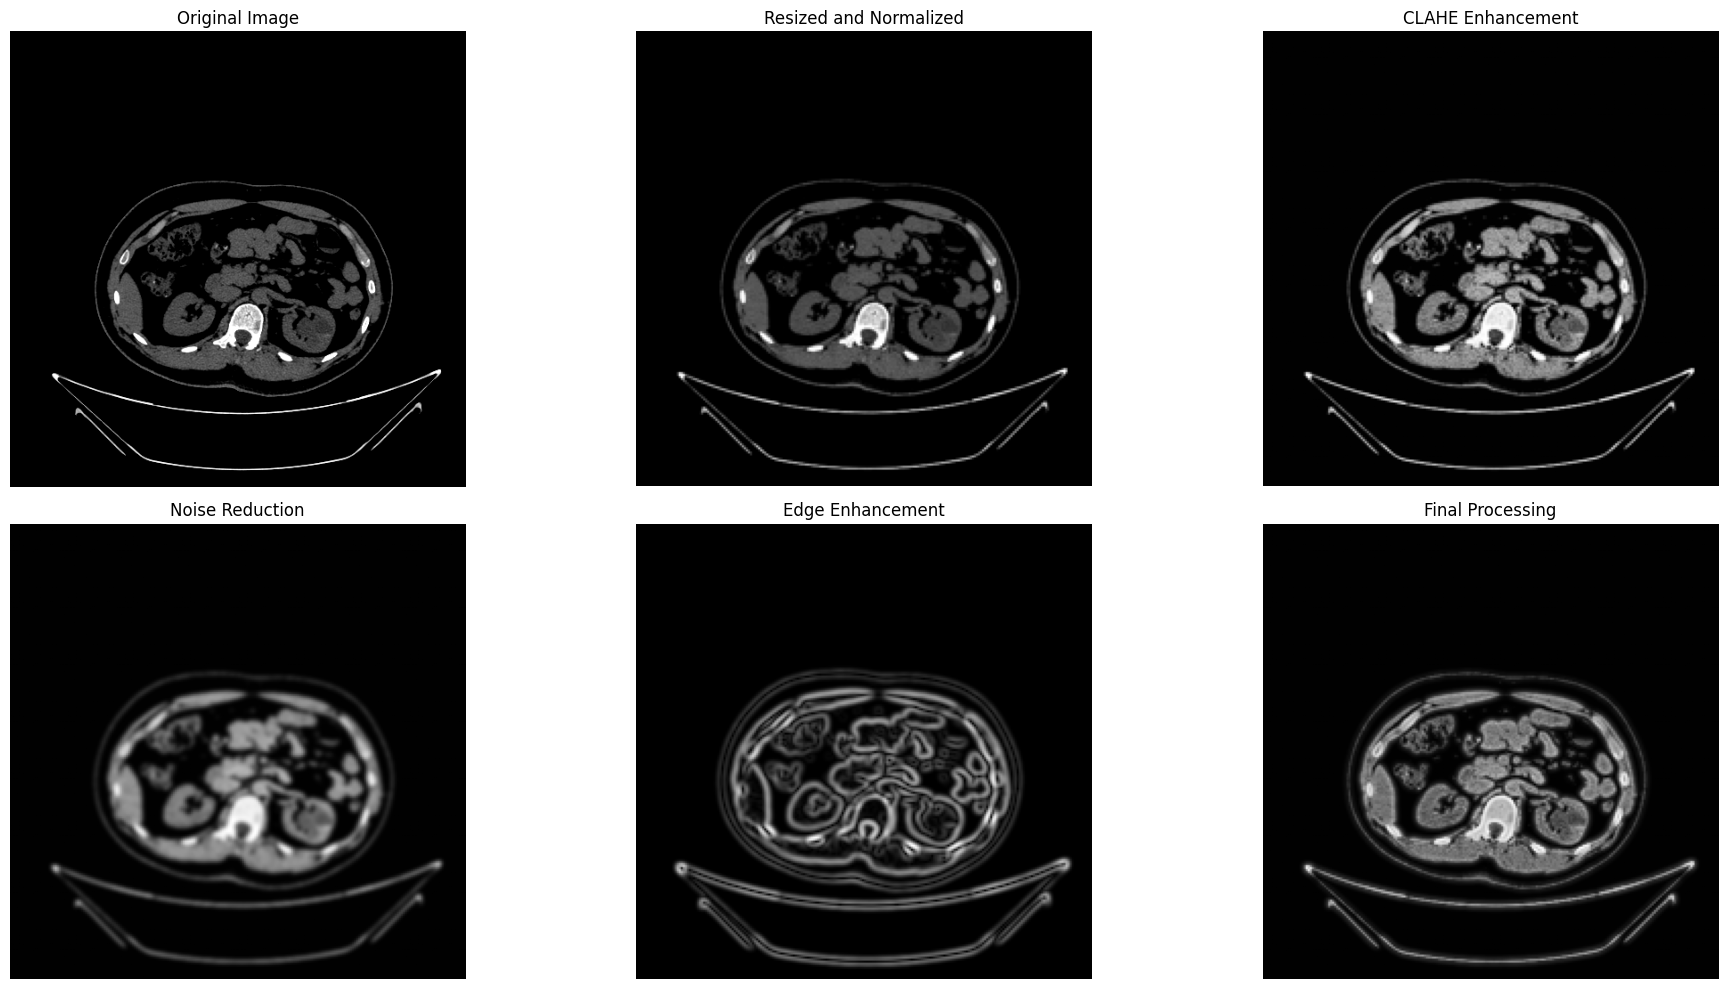

Found 1 images belonging to 1 classes.


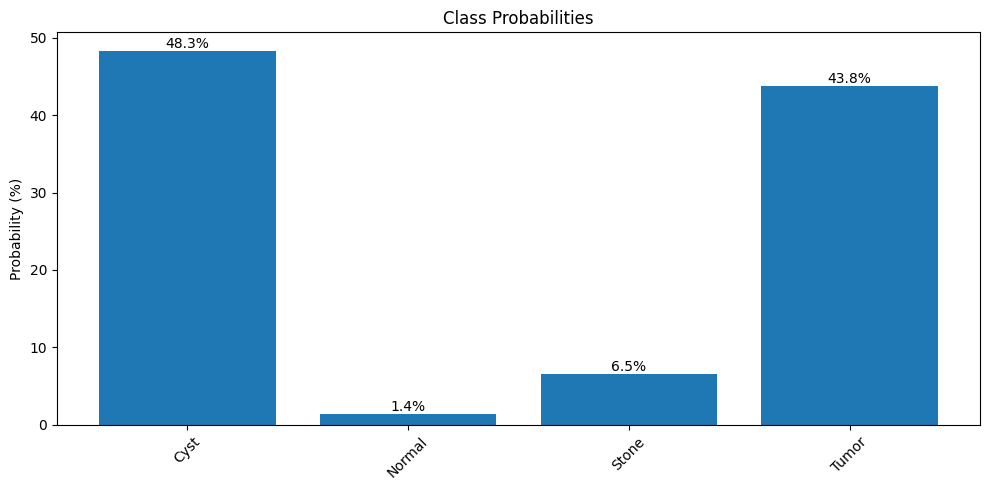


Detailed Analysis:
----------------------------------------
Image Characteristics:
Mean Intensity: 21.13
Standard Deviation: 38.49

Prediction Probabilities:
Cyst: 0.4830
Normal: 0.0140
Stone: 0.0651
Tumor: 0.4380

Final Prediction:
Class: Cyst
Confidence: 48.30%
Please upload a kidney CT scan image...


Saving Tumor- (1005).jpg to Tumor- (1005) (1).jpg

Visualizing Preprocessing Steps:


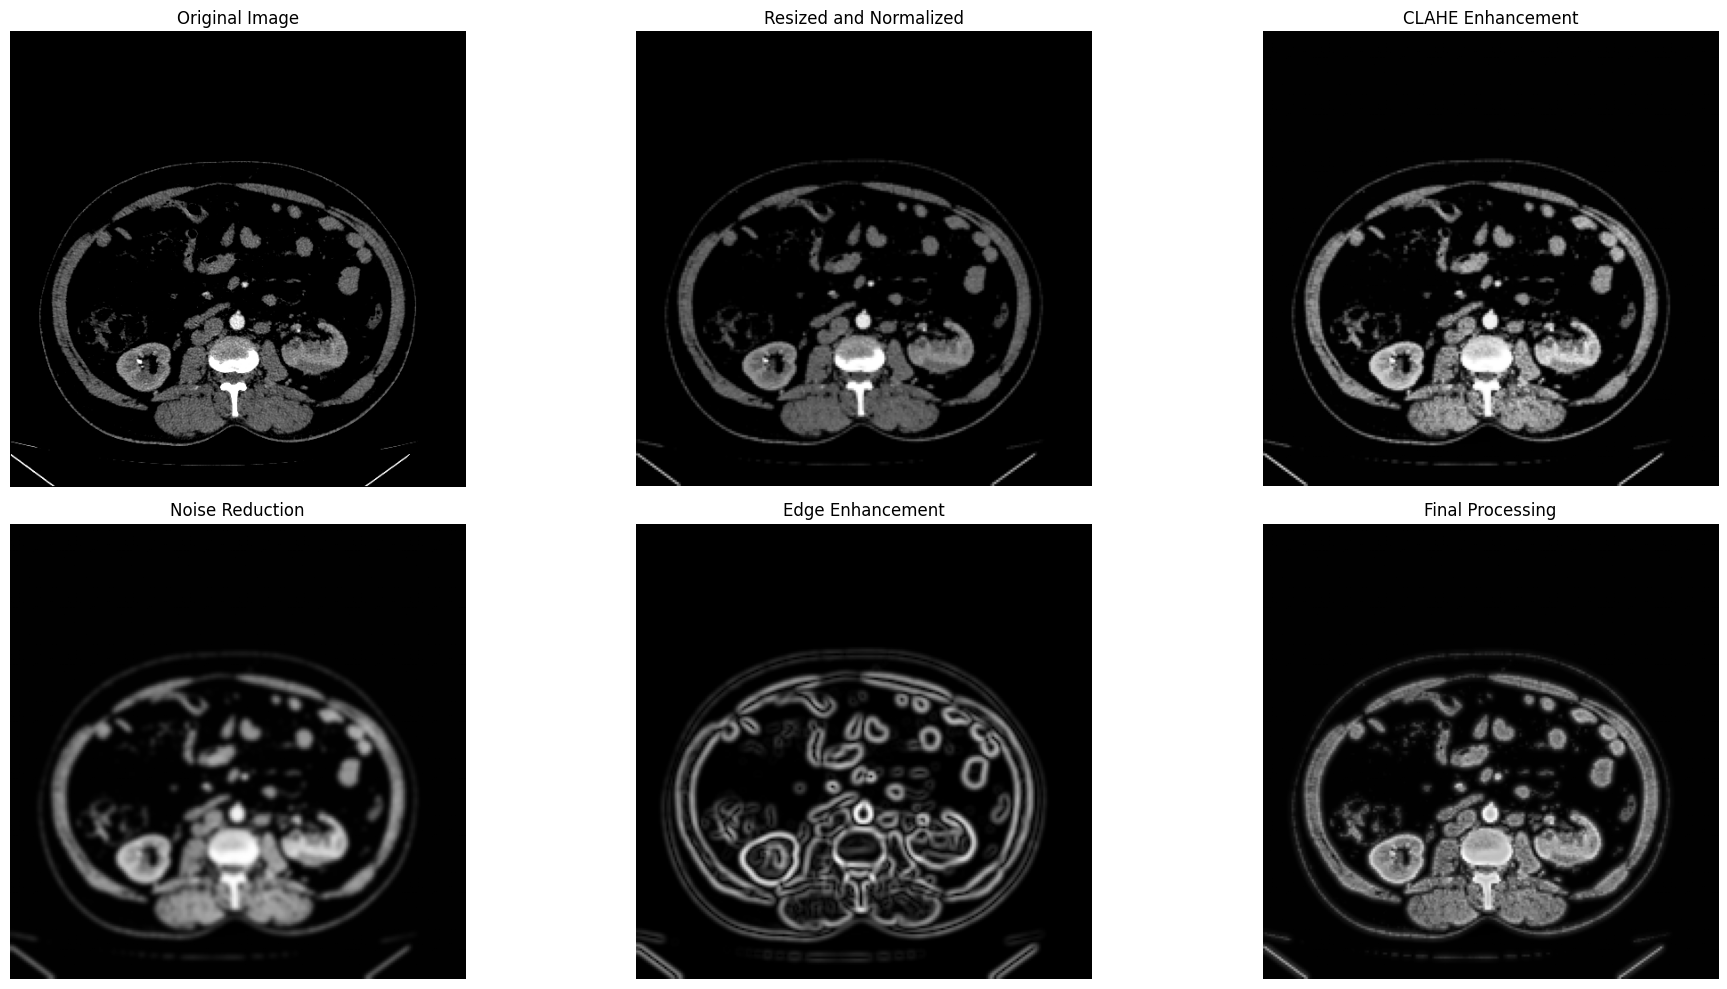

Found 1 images belonging to 1 classes.


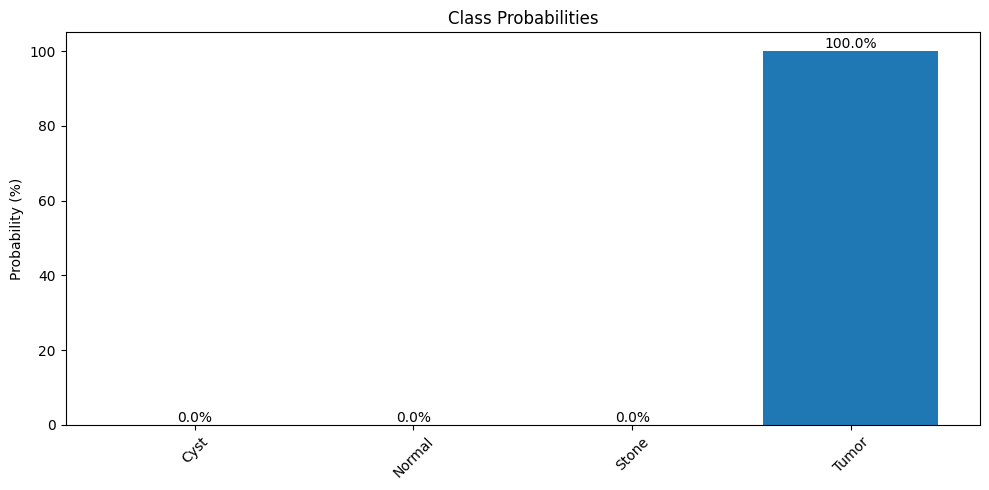


Detailed Analysis:
----------------------------------------
Image Characteristics:
Mean Intensity: 24.12
Standard Deviation: 41.98

Prediction Probabilities:
Cyst: 0.0000
Normal: 0.0000
Stone: 0.0000
Tumor: 1.0000

Final Prediction:
Class: Tumor
Confidence: 100.00%
Please upload a kidney CT scan image...


Saving Cyst- (1006).jpg to Cyst- (1006) (1).jpg

Visualizing Preprocessing Steps:


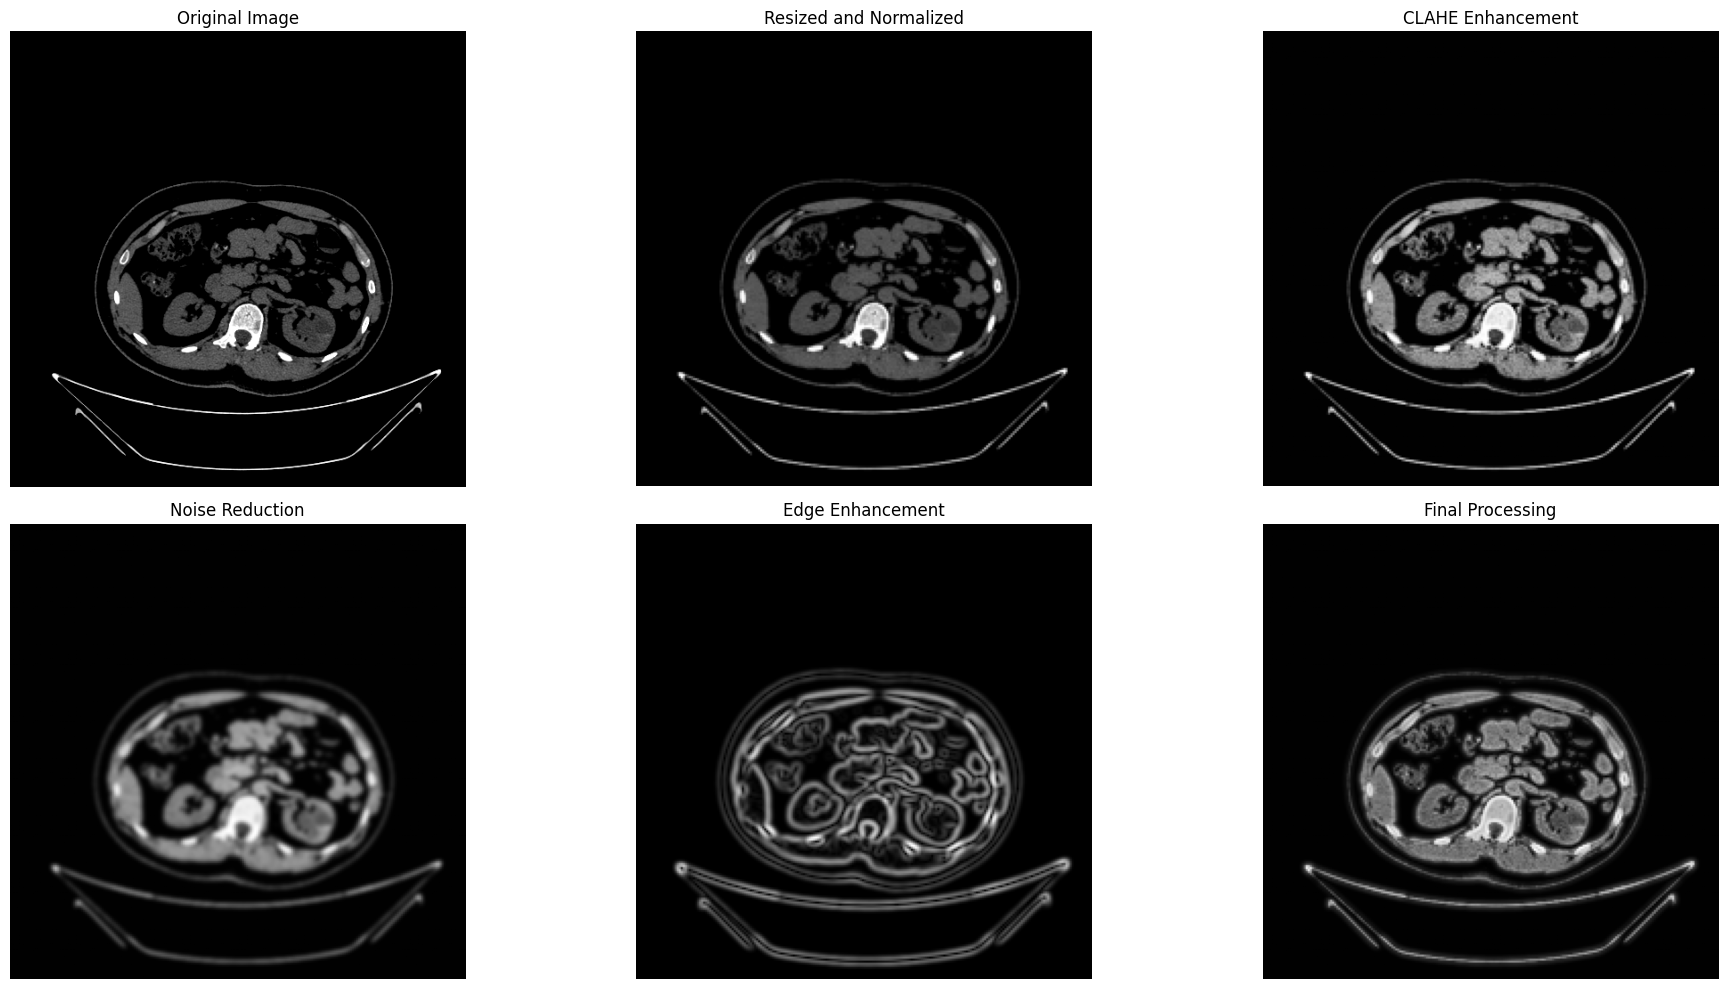

Found 1 images belonging to 1 classes.


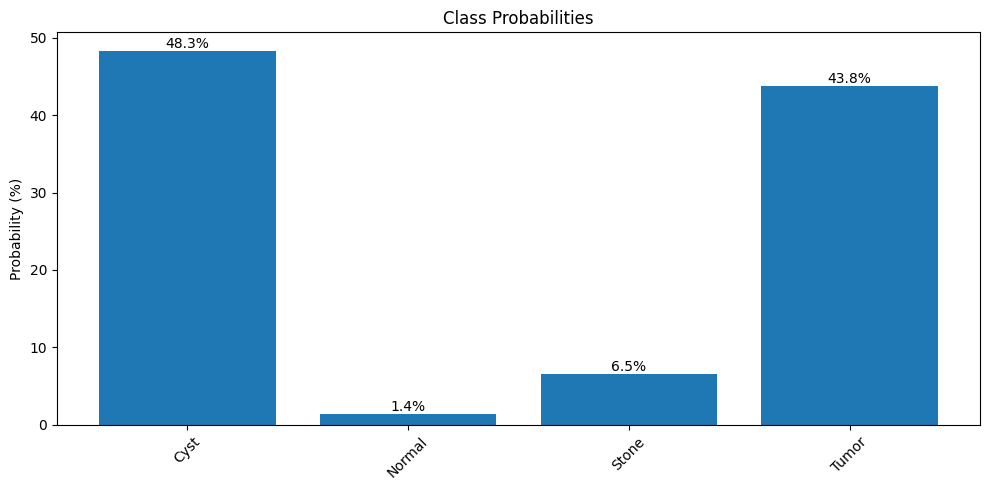


Detailed Analysis:
----------------------------------------
Image Characteristics:
Mean Intensity: 21.13
Standard Deviation: 38.49

Prediction Probabilities:
Cyst: 0.4830
Normal: 0.0140
Stone: 0.0651
Tumor: 0.4380

Final Prediction:
Class: Cyst
Confidence: 48.30%
Please upload a kidney CT scan image...


Saving Cyst- (1002) (2).jpg to Cyst- (1002) (2) (3).jpg

Visualizing Preprocessing Steps:


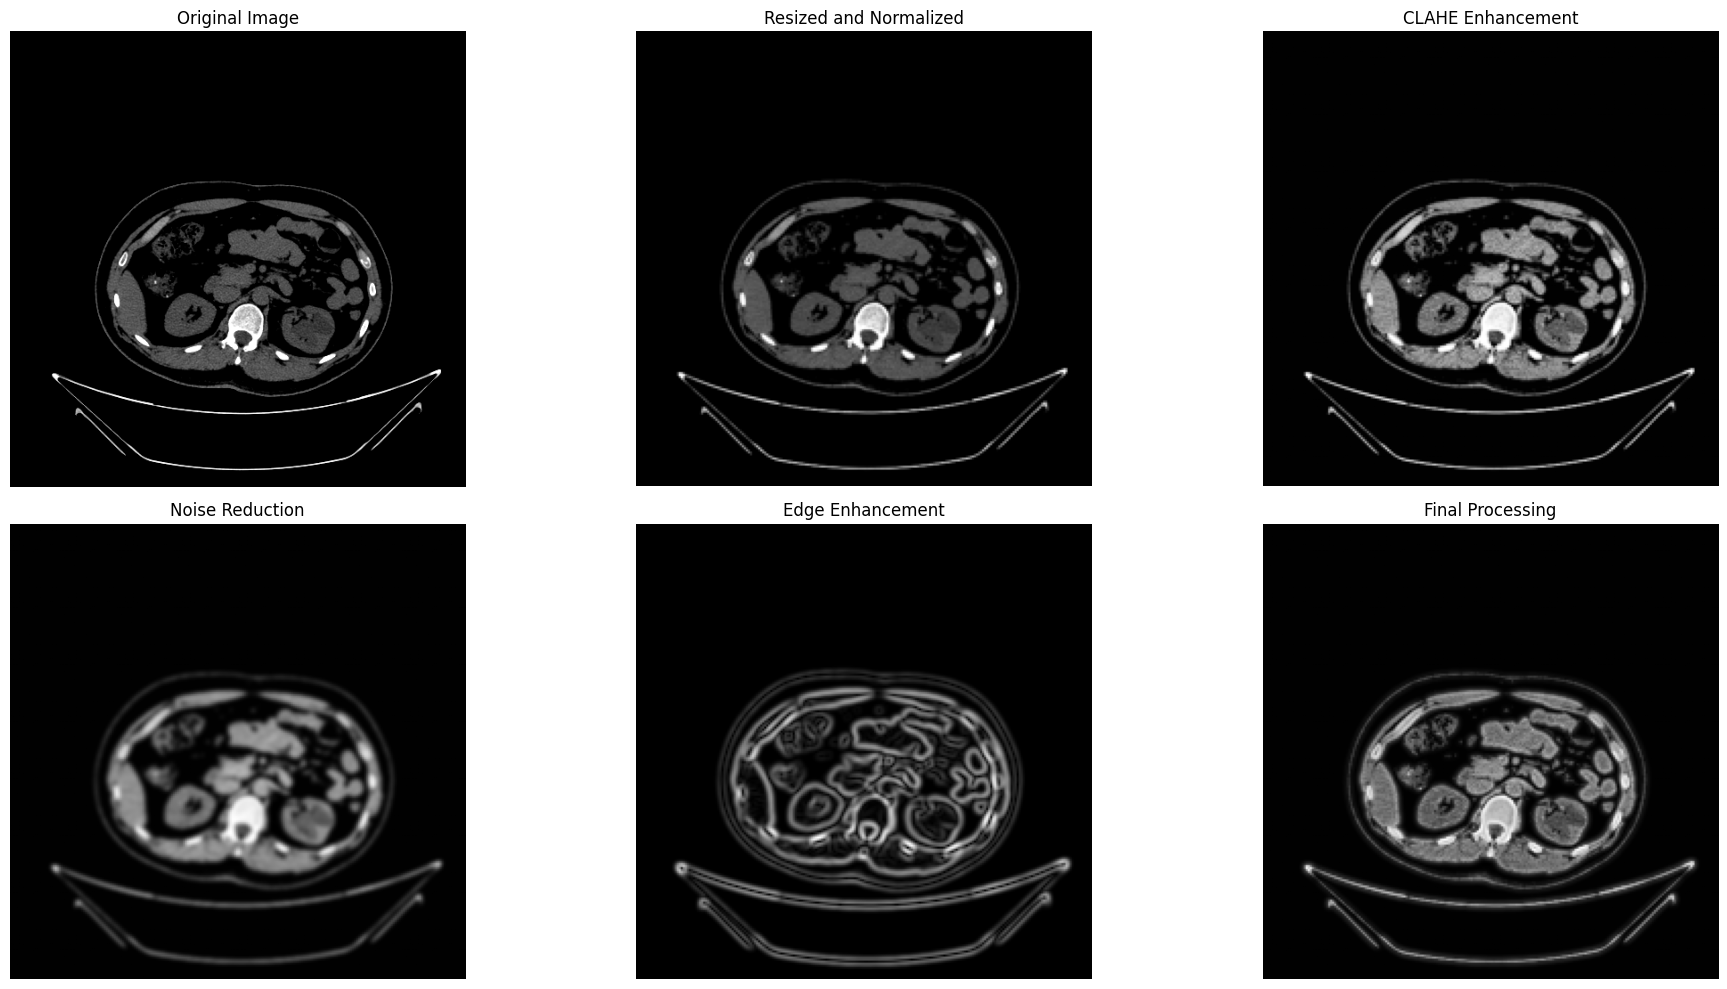

Found 1 images belonging to 1 classes.


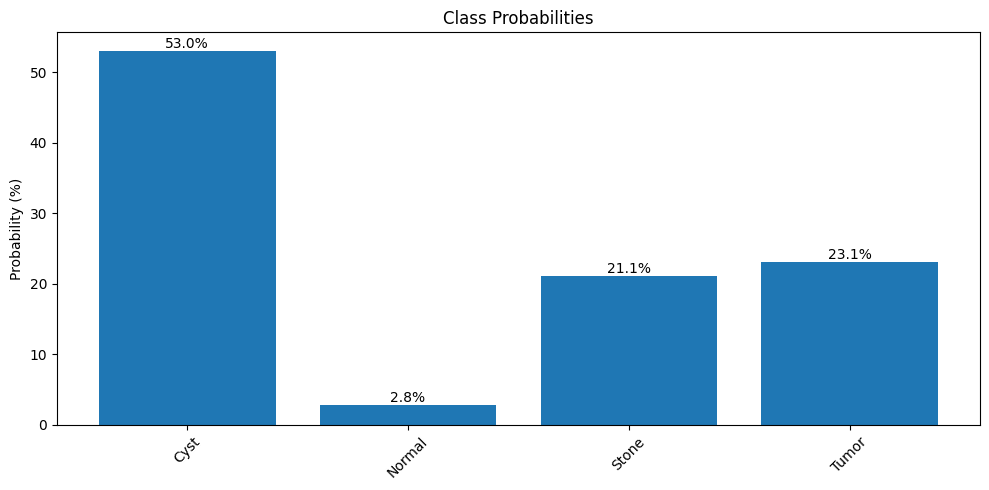


Detailed Analysis:
----------------------------------------
Image Characteristics:
Mean Intensity: 21.12
Standard Deviation: 38.52

Prediction Probabilities:
Cyst: 0.5305
Normal: 0.0277
Stone: 0.2113
Tumor: 0.2306

Final Prediction:
Class: Cyst
Confidence: 53.05%
Please upload a kidney CT scan image...


Saving Stone- (1001).jpg to Stone- (1001) (3).jpg

Visualizing Preprocessing Steps:


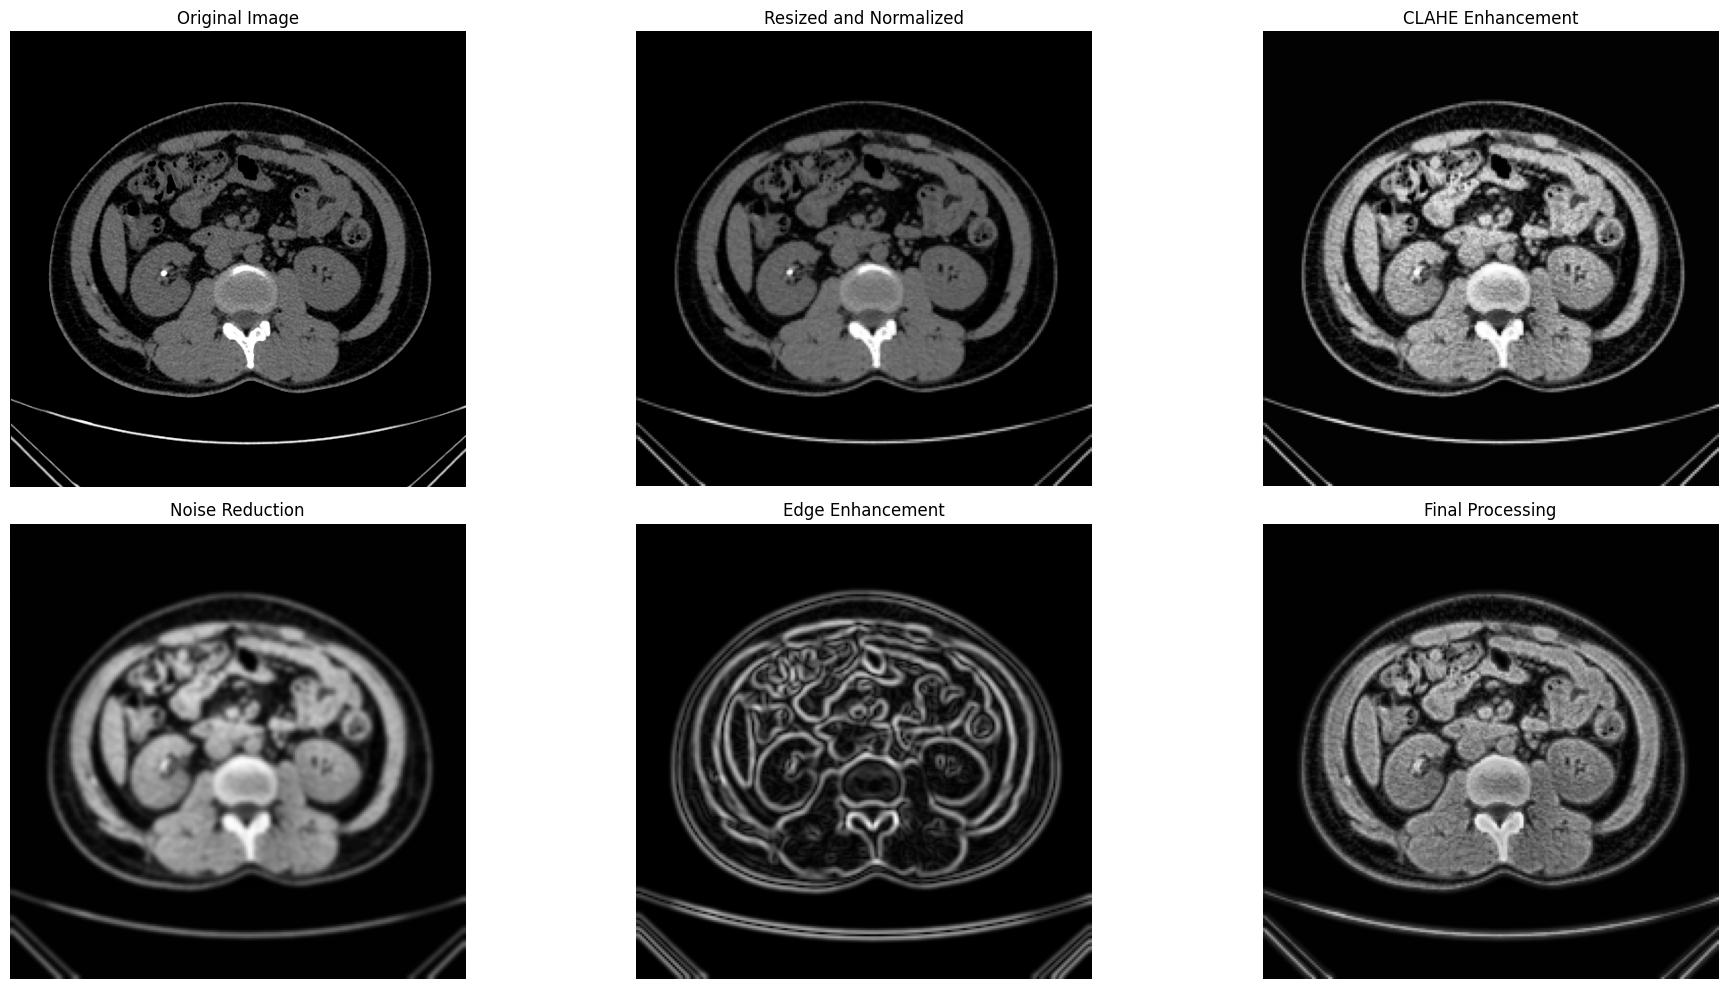

Found 1 images belonging to 1 classes.


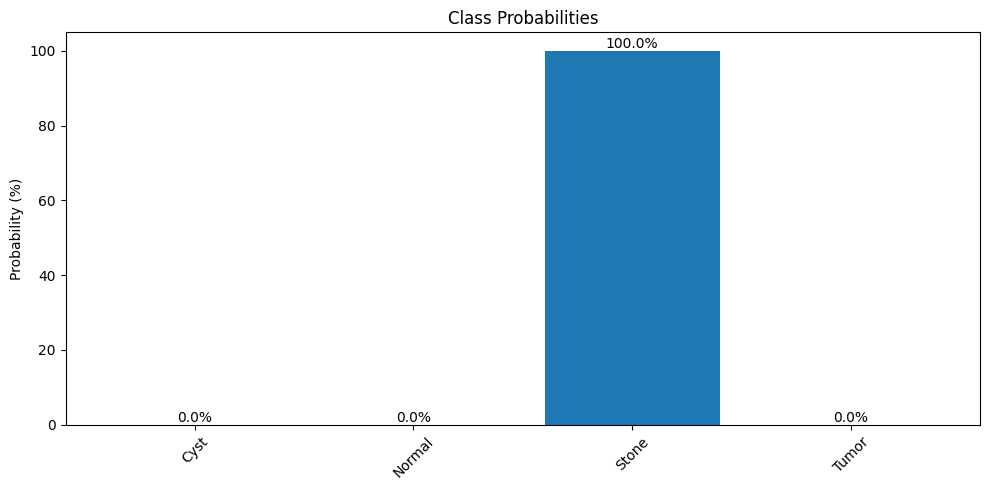


Detailed Analysis:
----------------------------------------
Image Characteristics:
Mean Intensity: 42.87
Standard Deviation: 53.49

Prediction Probabilities:
Cyst: 0.0002
Normal: 0.0000
Stone: 0.9998
Tumor: 0.0000

Final Prediction:
Class: Stone
Confidence: 99.98%
Please upload a kidney CT scan image...


Saving Cyst- (104).jpg to Cyst- (104) (2).jpg

Visualizing Preprocessing Steps:


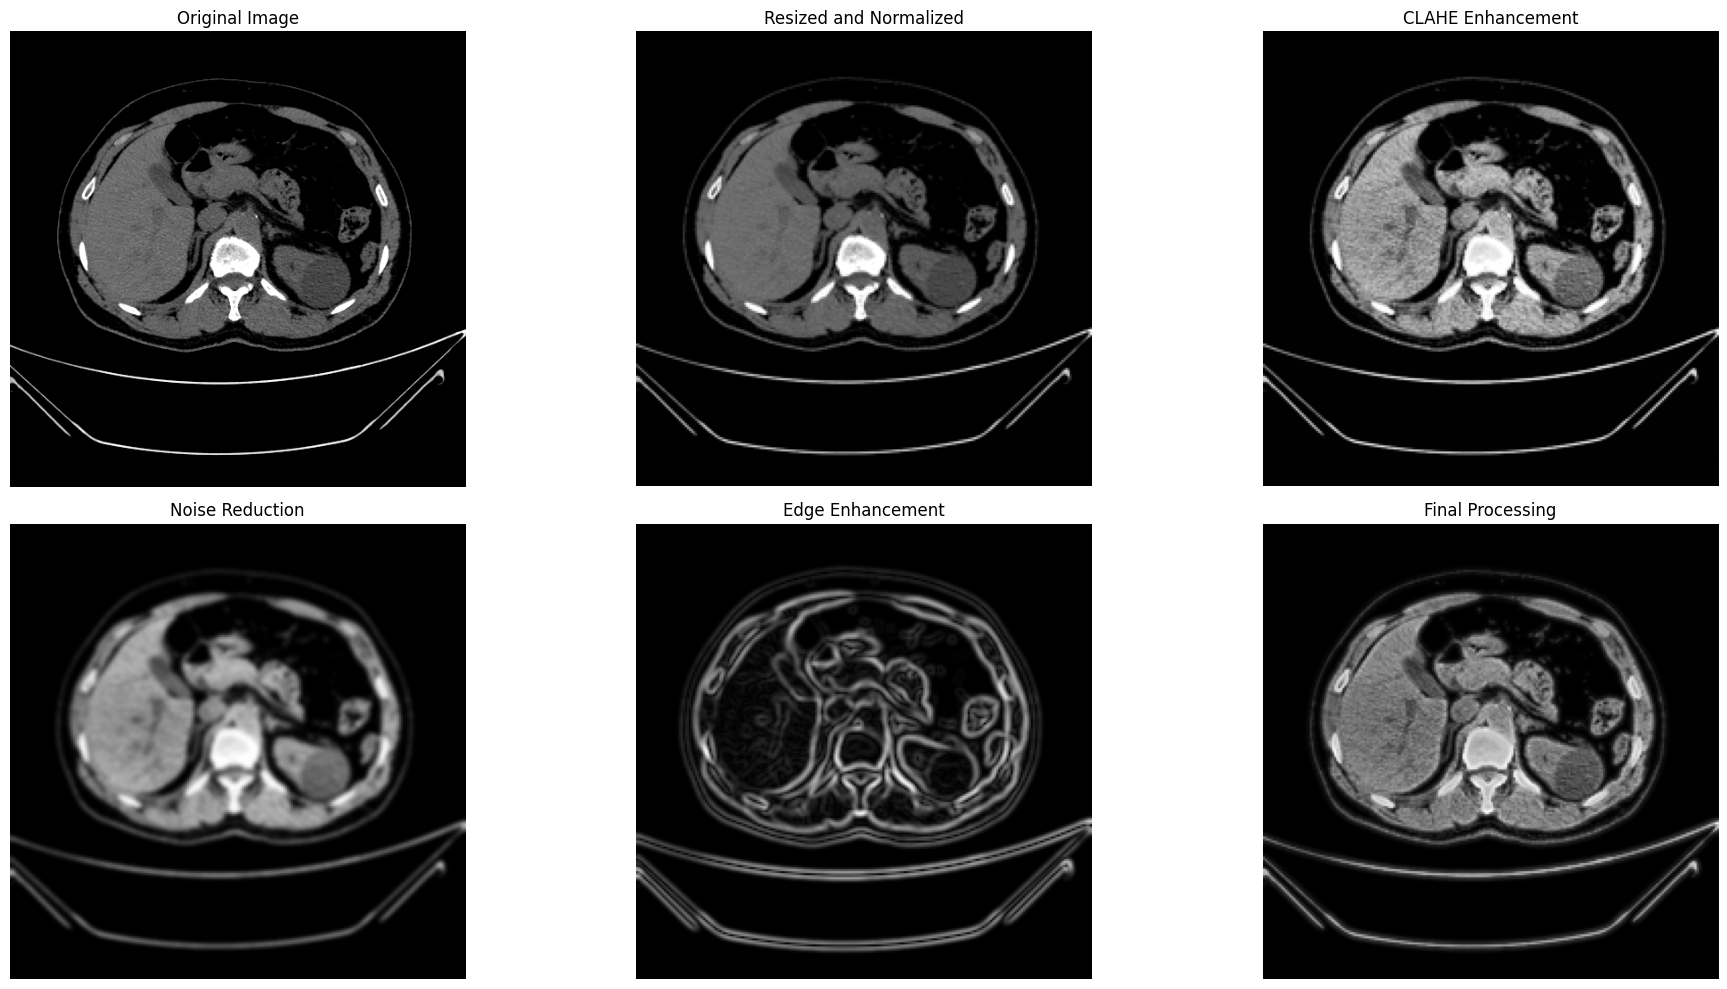

Found 1 images belonging to 1 classes.


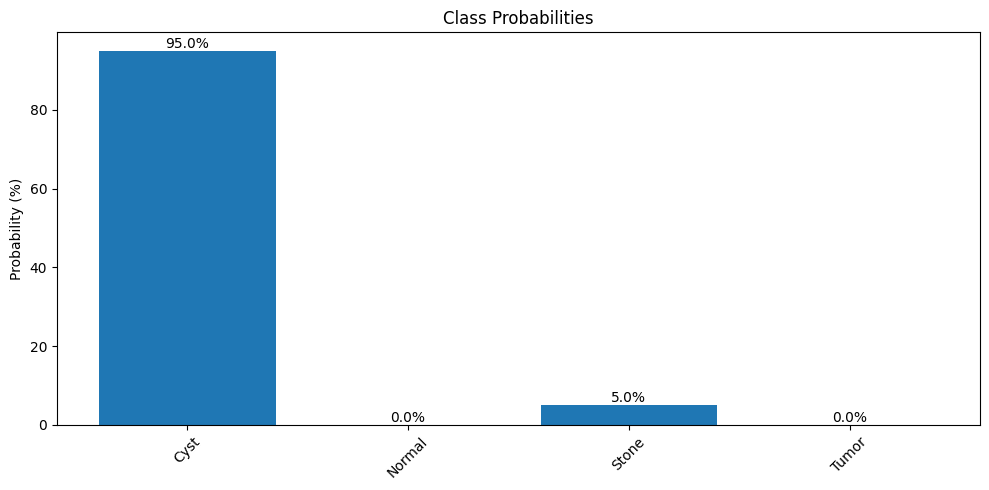


Detailed Analysis:
----------------------------------------
Image Characteristics:
Mean Intensity: 34.63
Standard Deviation: 49.13

Prediction Probabilities:
Cyst: 0.9495
Normal: 0.0000
Stone: 0.0503
Tumor: 0.0002

Final Prediction:
Class: Cyst
Confidence: 94.95%

Would you like to analyze another image? (yes/no): no


In [56]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
from google.colab import files
import tempfile
import shutil

def analyze_single_image(image_path, model_path, target_size=(224, 224)):
    """
    Analyze a single kidney CT image and provide detailed output.

    Args:
        image_path: Path to the input image
        model_path: Path to the trained model
        target_size: Target size for image resizing
    """
    # Load the model
    model = tf.keras.models.load_model(model_path)

    # Class labels
    class_labels = ['Cyst', 'Normal', 'Stone', 'Tumor']

    try:
        # Read and preprocess the image
        img = Image.open(image_path)
        img = img.resize(target_size)
        img_array = np.array(img)

        # Convert grayscale to RGB if needed
        if len(img_array.shape) == 2:
            img_array = np.stack((img_array,) * 3, axis=-1)
        elif img_array.shape[2] == 1:
            img_array = np.repeat(img_array, 3, axis=2)

        # Enhanced preprocessing
        gray_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        enhanced_img = clahe.apply(gray_img)
        blurred_img = cv2.GaussianBlur(enhanced_img, (5,5), 0)

        # Apply Otsu's thresholding
        _, thresh = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Find contours
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Create mask
        mask = np.zeros_like(gray_img)
        for contour in contours:
            area = cv2.contourArea(contour)
            if 100 < area < 10000:
                cv2.drawContours(mask, [contour], -1, 255, -1)

        # Analyze characteristics
        mean_intensity = np.mean(enhanced_img[mask > 0])
        std_intensity = np.std(enhanced_img[mask > 0])

        # Calculate circularity
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest_contour)
            perimeter = cv2.arcLength(largest_contour, True)
            circularity = 4 * np.pi * area / (perimeter * perimeter) if perimeter > 0 else 0
        else:
            circularity = 0

        # Prepare image for prediction
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Make prediction
        predictions = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(predictions[0])
        confidence = predictions[0][predicted_class]
        class_probabilities = predictions[0] * 100

        # Display results
        plt.figure(figsize=(20, 5))

        # Original image
        plt.subplot(1, 4, 1)
        plt.imshow(img)
        plt.title('Original Image')
        plt.axis('off')

        # Enhanced image
        plt.subplot(1, 4, 2)
        plt.imshow(enhanced_img, cmap='gray')
        plt.title('Enhanced Image')
        plt.axis('off')

        # Mask
        plt.subplot(1, 4, 3)
        plt.imshow(mask, cmap='gray')
        plt.title('Detected Regions')
        plt.axis('off')

        # Probability chart
        plt.subplot(1, 4, 4)
        bars = plt.bar(class_labels, class_probabilities)
        plt.title('Class Probabilities')
        plt.ylabel('Probability (%)')
        plt.xticks(rotation=45)

        # Add probability values
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        # Print detailed results
        print("\nDetailed Analysis:")
        print("-" * 40)
        print("Image Characteristics:")
        print(f"Mean Intensity: {mean_intensity:.2f}")
        print(f"Standard Deviation: {std_intensity:.2f}")
        print(f"Circularity: {circularity:.2f}")

        print("\nPrediction Probabilities:")
        for label, prob in zip(class_labels, class_probabilities):
            print(f"{label}: {prob:.2f}%")

        print("\nFinal Prediction:")
        print(f"Class: {class_labels[predicted_class]}")
        print(f"Confidence: {confidence:.2%}")

        # Check for potential misclassification
        if predicted_class == 3:  # If predicted as tumor
            # More specific conditions for cyst misclassification
            cyst_probability = class_probabilities[0]
            tumor_probability = class_probabilities[3]

            # Check if cyst probability is significant and close to tumor probability
            if (cyst_probability > 20 and  # Higher threshold for cyst probability
                tumor_probability - cyst_probability < 15 and  # Small difference between tumor and cyst probabilities
                circularity > 0.6 and  # Cysts are typically more circular
                mean_intensity < 150):  # Cysts typically have lower intensity

                print("\nWarning: Potential Cyst Misclassification Detected!")
                print("The image shows characteristics typical of a cyst:")
                print(f"- High circularity ({circularity:.2f})")
                print(f"- Low mean intensity ({mean_intensity:.2f})")
                print(f"- Significant cyst probability ({cyst_probability:.1f}%)")
                print("Please review the detected regions carefully.")

        return {
            'predicted_class': class_labels[predicted_class],
            'confidence': confidence,
            'probabilities': dict(zip(class_labels, class_probabilities)),
            'characteristics': {
                'mean_intensity': mean_intensity,
                'std_intensity': std_intensity,
                'circularity': circularity
            }
        }

    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None

def analyze_multiple_images(image_dir, model_path):
    """
    Analyze multiple images from a directory.

    Args:
        image_dir: Directory containing images to analyze
        model_path: Path to the trained model
    """
    results = {}

    # Get all image files
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for image_file in image_files:
        print(f"\nAnalyzing {image_file}...")
        image_path = os.path.join(image_dir, image_file)
        result = analyze_single_image(image_path, model_path)
        if result:
            results[image_file] = result

    return results

def visualize_preprocessing_steps(image_path, target_size=(224, 224)):
    """
    Visualize all preprocessing steps for a kidney CT image.

    Args:
        image_path: Path to the input image
        target_size: Target size for image resizing
    """
    try:
        # Read original image
        img = Image.open(image_path)
        original_img = np.array(img)

        # Resize and normalize
        img = img.resize(target_size)
        resized_img = np.array(img)
        normalized_img = resized_img / 255.0

        # Convert to grayscale for processing
        gray_img = cv2.cvtColor(resized_img, cv2.COLOR_RGB2GRAY)

        # CLAHE Enhancement
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        clahe_img = clahe.apply(gray_img)

        # Noise Reduction (Gaussian Blur)
        noise_reduced_img = cv2.GaussianBlur(clahe_img, (5,5), 0)

        # Edge Enhancement (Sobel)
        sobelx = cv2.Sobel(noise_reduced_img, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(noise_reduced_img, cv2.CV_64F, 0, 1, ksize=3)
        edge_enhanced_img = np.sqrt(sobelx**2 + sobely**2)
        edge_enhanced_img = np.uint8(edge_enhanced_img * 255 / np.max(edge_enhanced_img))

        # Final Processing (Combine CLAHE and Edge Enhancement)
        final_img = cv2.addWeighted(clahe_img, 0.7, edge_enhanced_img, 0.3, 0)

        # Create figure with subplots
        plt.figure(figsize=(20, 10))

        # Original Image
        plt.subplot(2, 3, 1)
        plt.imshow(original_img)
        plt.title('Original Image')
        plt.axis('off')

        # Resized and Normalized
        plt.subplot(2, 3, 2)
        plt.imshow(normalized_img)
        plt.title('Resized and Normalized')
        plt.axis('off')

        # CLAHE Enhancement
        plt.subplot(2, 3, 3)
        plt.imshow(clahe_img, cmap='gray')
        plt.title('CLAHE Enhancement')
        plt.axis('off')

        # Noise Reduction
        plt.subplot(2, 3, 4)
        plt.imshow(noise_reduced_img, cmap='gray')
        plt.title('Noise Reduction')
        plt.axis('off')

        # Edge Enhancement
        plt.subplot(2, 3, 5)
        plt.imshow(edge_enhanced_img, cmap='gray')
        plt.title('Edge Enhancement')
        plt.axis('off')

        # Final Processing
        plt.subplot(2, 3, 6)
        plt.imshow(final_img, cmap='gray')
        plt.title('Final Processing')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # Return all processed images
        return {
            'original': original_img,
            'resized_normalized': normalized_img,
            'clahe': clahe_img,
            'noise_reduced': noise_reduced_img,
            'edge_enhanced': edge_enhanced_img,
            'final': final_img
        }

    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None

def analyze_uploaded_image(model_path, target_size=(224, 224)):
    """
    Upload and analyze a kidney CT image using Google Colab's file upload.

    Args:
        model_path: Path to the trained model
        target_size: Target size for image resizing
    """
    # Load the model
    model = tf.keras.models.load_model(model_path)

    # Class labels
    class_labels = ['Cyst', 'Normal', 'Stone', 'Tumor']

    try:
        # Upload image
        print("Please upload a kidney CT scan image...")
        uploaded = files.upload()

        if not uploaded:
            print("No file was uploaded. Please try again.")
            return None

        # Get the uploaded file
        filename = list(uploaded.keys())[0]

        # Save the uploaded file temporarily
        with tempfile.NamedTemporaryFile(delete=False, suffix=os.path.splitext(filename)[1]) as tmp_file:
            tmp_file.write(uploaded[filename])
            temp_path = tmp_file.name

        try:
            # Visualize preprocessing steps
            print("\nVisualizing Preprocessing Steps:")
            print("=" * 50)
            processed_images = visualize_preprocessing_steps(temp_path, target_size)

            if not processed_images:
                return None

            # Create a temporary directory for ImageDataGenerator
            temp_dir = tempfile.mkdtemp()
            temp_subdir = os.path.join(temp_dir, 'temp')
            os.makedirs(temp_subdir, exist_ok=True)

            # Copy the uploaded file to the temporary directory
            shutil.copy2(temp_path, os.path.join(temp_subdir, filename))

            # Create data generator with same preprocessing as training
            datagen = ImageDataGenerator(rescale=1./255)

            # Create generator for the single image
            generator = datagen.flow_from_directory(
                temp_dir,
                target_size=target_size,
                batch_size=1,
                class_mode='categorical',
                shuffle=False
            )

            # Make prediction using ImageDataGenerator
            predictions = model.predict(generator, verbose=0)
            predicted_class = np.argmax(predictions[0])
            confidence = predictions[0][predicted_class]
            class_probabilities = predictions[0]

            # Display prediction results
            plt.figure(figsize=(10, 5))
            bars = plt.bar(class_labels, class_probabilities * 100)
            plt.title('Class Probabilities')
            plt.ylabel('Probability (%)')
            plt.xticks(rotation=45)

            # Add probability values
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}%',
                        ha='center', va='bottom')

            plt.tight_layout()
            plt.show()

            # Print detailed results
            print("\nDetailed Analysis:")
            print("-" * 40)
            print("Image Characteristics:")
            print(f"Mean Intensity: {np.mean(processed_images['final']):.2f}")
            print(f"Standard Deviation: {np.std(processed_images['final']):.2f}")

            print("\nPrediction Probabilities:")
            for label, prob in zip(class_labels, class_probabilities):
                print(f"{label}: {prob:.4f}")

            print("\nFinal Prediction:")
            print(f"Class: {class_labels[predicted_class]}")
            print(f"Confidence: {confidence:.2%}")

            return {
                'predicted_class': class_labels[predicted_class],
                'confidence': confidence,
                'probabilities': dict(zip(class_labels, class_probabilities)),
                'processed_images': processed_images
            }

        finally:
            # Clean up temporary files
            os.unlink(temp_path)
            shutil.rmtree(temp_dir)

    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None

def analyze_multiple_uploads(model_path):
    """
    Continuously analyze uploaded images until user stops.

    Args:
        model_path: Path to the trained model
    """
    while True:
        result = analyze_uploaded_image(model_path)

        if result:
            # Ask if user wants to continue
            response = input("\nWould you like to analyze another image? (yes/no): ").lower()
            if response != 'yes':
                break
        else:
            # Ask if user wants to try again
            response = input("\nWould you like to try again? (yes/no): ").lower()
            if response != 'yes':
                break

# Example usage:
if __name__ == "__main__":
    # Set model path
    model_path = '/content/models/kidney_disease_model_20250424_221407.keras'

    print("Kidney Disease Classification - Image Analysis")
    print("=" * 50)
    print("This tool will analyze kidney CT scan images and provide detailed predictions.")
    print("Please upload an image when prompted.")

    # Start the analysis interface
    analyze_multiple_uploads(model_path)

In [61]:
import shutil
import os
# from google.colab import drive  # Remove or comment out drive.mount

# Source Paths (Separate Files and Folders)
source_folders = [
    "/content/1",
    "/content/models",
    "/content/kidney_dataset",
    "/content/true_positives"
]
source_files = [
    "/content/best_model.h5",
    "/content/kaggle.json"
]

destination_folder = "/content/drive/MyDrive/DIP KDP"

# Custom Function to Handle Existing Directories (for folders)
def copytree_with_overwrite(src, dst):
    if os.path.exists(dst):
        shutil.rmtree(dst)  # Remove the existing directory
    shutil.copytree(src, dst)

# Copy Folders
for folder in source_folders:
    copytree_with_overwrite(folder, os.path.join(destination_folder, os.path.basename(folder)))

# Copy Files
for file in source_files:
    shutil.copy2(file, destination_folder)  # Copy files directly to the destination folder

print("Folders and files copied successfully!")

Folders and files copied successfully!
